# Prior visualisation — LGD (Loss Given Default)

**Which of Experiment 1's 32 priors is best?** That is the only question this notebook
answers, and every figure is here because it helps answer it.

Exp1 trains one model per prior at a short budget and ranks them. Before spending that
compute, these figures check the priors are worth training on at all: do they look like
real credit data, do their mechanisms produce the structure we claim, and is the task
the right difficulty?

Figures that did **not** answer it have been removed — a target histogram for PD is one
number drawn as a picture, and correlation heatmaps of random synthetic features only
show that random graphs make random correlations.


In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import exp1_plots as e1, figures, pool_plots as pp, mechanism_plots, prior_plots, style, summaries

style.apply()   # ONE shared style: identical colours in every notebook
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK   = "lgd"
CONFIG = "config/Exp1_LGD.yaml"   # Exp1 is the prior sweep, so it is the one to visualise
N      = 500     # datasets to draw per prior - enough to show the structure
FOCUS  = None    # variant for the detail plots; None = the first non-original one

# Clears THIS notebook's figure folder - and no other - BEFORE anything is drawn, then saves
# every figure as a PDF sized for A4. Identical in Jupyter and under the batch runner.
FIGS = figures.FigureSaver("prior_visualisation_lgd")


### What the colours mean

Set once in `src/visualize/style.py`, identical in every notebook.


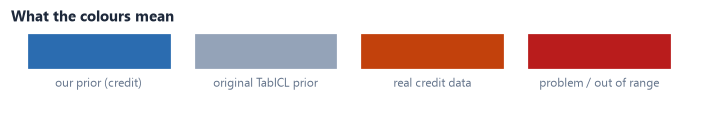

In [2]:
FIGS.save(
    style.show_palette(),
    "palette",
    caption=(
"Colour key. Grey denotes the unmodified TabICL prior, blue the credit-targeted "
"prior, orange values measured from the real datasets, and red out-of-range or "
"flagged values."
    ),
);


## 1. Load the priors and the real data


In [3]:
variants = pp.discover_pools(TASK)
print("pools found:", ", ".join(variants) if variants else "none - will generate live")
loaded, SOURCE = pp.load_variants_or_generate(TASK, n=N, seed=0, config=CONFIG)
print("source =", SOURCE)
print({k: len(v) for k, v in loaded.items()})

FOCUS = FOCUS or next((k for k in loaded if not k.startswith("original")), list(loaded)[0])
print("FOCUS (detail plots) =", FOCUS)

# The real datasets, for every comparison below. Without them the figures describe the prior in
# isolation, which is the thing that made the old notebook uninformative.
REAL = summaries.load_real_datasets(TASK)
print(f"real {TASK.upper()} datasets loaded: {len(REAL)}")
REFERENCE = pp.real_reference(TASK)


pools found: none - will generate live
no pools found for lgd — generating 500 datasets per arm live from config/Exp1_LGD.yaml


c:\Users\U0152019\PhD Documents\Projects\4. CreditICL\CreditICL\.CreditICL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source = live
{'original (live)': 500, 'credit (live)': 500}
FOCUS (detail plots) = credit (live)
real LGD datasets loaded: 7
reference: measured from 7 real LGD datasets


## 2. Summary table

Shapes, target statistics and how each prior compares numerically.


In [4]:
pp.variant_summary(loaded, TASK)


,variant,n_sampled,rows_median,features_median,"in [0,1]",boundary mass mean,boundary p10,boundary p90,any atoms
0,original (live),500,1024,100,0.006,0.1052,0.002,0.3529,0.498
1,credit (live),500,1024,100,1.000,0.3170,0.168,0.4593,1.000


## 3. Which prior looks most like real credit data?

**The figure to read first.** For each prior, how far its target distribution sits from
each real LGD dataset's, as a total-variation distance. Lower is better.

A distance rather than side-by-side histograms because 32 priors cannot be compared by
eye. The spread of the dots matters as much as the mean: a prior that matches one
dataset and misses the rest is not a good prior.


**How to read it.** One row per prior, best at the top. Grey dots are the individual real datasets and the blue diamond their mean, so a wide spread means the prior matches some datasets and misses others — worse than a slightly larger mean with dots close together.

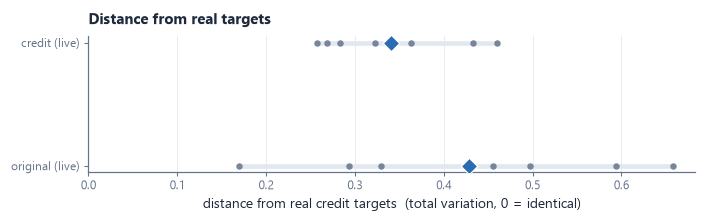

In [5]:
FIGS.save(
    e1.plot_prior_realism_ranking(loaded, REAL, task=TASK),
    "prior_realism_ranking",
    caption=(
"Distance between each prior variant's pooled target distribution and each real LGD "
"dataset's, as total variation over 40 fixed bins. Diamonds give the mean across "
"datasets, dots one per dataset. Variants ordered by mean distance."
    ),
);


## 4. Where do the boundary atoms come from?

**The paper's central claim as a picture.** Our prior derives the loss from a credit
story — collateral, workout, or a mixture of portfolio segments — so the mass at 0
(full recovery) and at 1 (total loss) is a *consequence* of that story rather than a
parameter we set.

If the claim holds, `collateral` should own most of the atom at 0: an
over-collateralised loan recovers in full by construction.


**How to read it.** Each panel is one loss story. The spikes at 0 and 1 are what we claim *emerges* from the economics: `collateral` should own most of the mass at 0, because an over-collateralised loan recovers in full by construction.

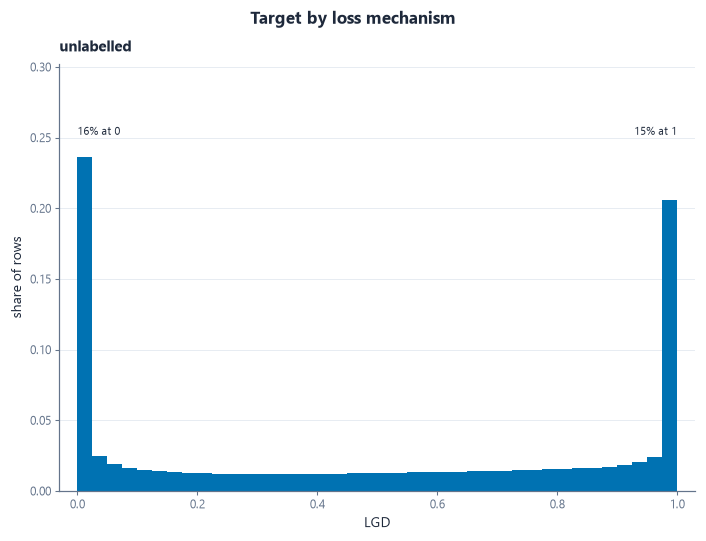

In [6]:
FIGS.save(
        e1.plot_mechanism_decomposition(loaded[FOCUS]),
        "mechanism_decomposition",
        caption=(
"Distribution of the LGD target, split by the loss mechanism that generated each "
"synthetic dataset, 40 bins per panel on a fixed [0,1] support. Percentages give the "
"share of rows lying exactly at 0 and exactly at 1. Panel subtitles give the number "
"of datasets per mechanism."
        ),
    );


## 5. Which boundary does the mass sit on?

Total boundary mass hides the asymmetry that matters. A book where most defaults
recover in full is a different book from one where most are a total loss, and both
can share the same total. Stars are the real datasets — a prior should land where
they are.


**How to read it.** Magenta stars are the real datasets; coloured dots are synthetic ones. A prior lands well if its cloud sits where the stars are. Above the dotted diagonal means loss-heavy, below it recovery-heavy.

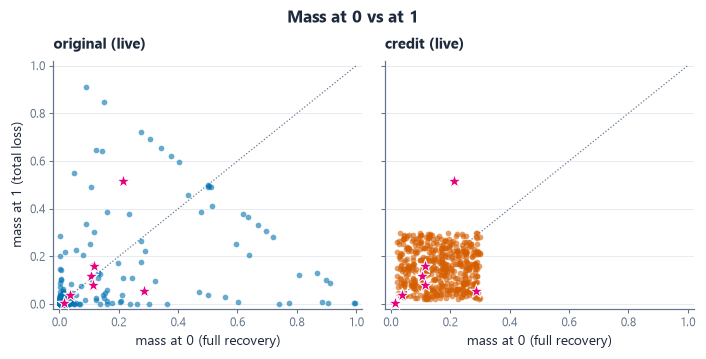

In [7]:
FIGS.save(
        e1.plot_boundary_mass_sources(loaded, REAL),
        "boundary_mass_sources",
        caption=(
"Share of rows at exactly 0 against share at exactly 1, one point per synthetic "
"dataset and one panel per prior variant. Stars mark the real LGD datasets. The "
"dotted diagonal is equal mass at both ends."
        ),
    );


## 6. Target shapes, one row per prior

Kept for LGD because the *shape* of a bounded target is genuinely informative — U,
J, or flat interior, and how the atoms sit against it. Paginated: ten panels across
A4 would be 0.63 in each.


**How to read it.** Rows share a draw index, so panels in the same column come from the same random seed and are directly comparable across priors.

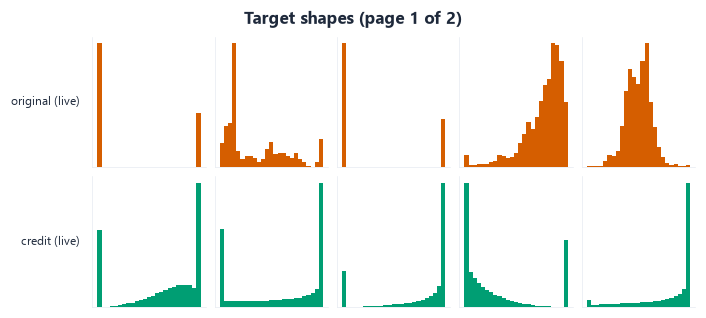

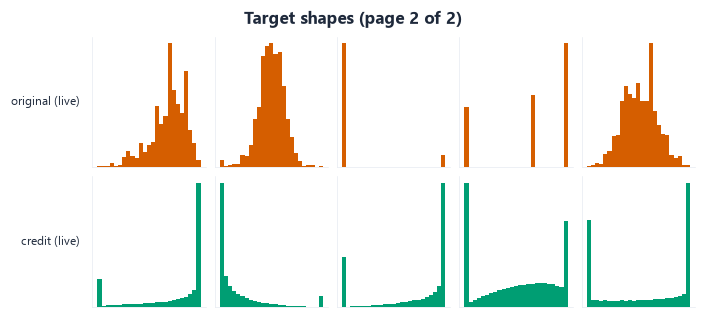

In [8]:
for _page in range(1, pp.shape_pages(n_per=10) + 1):
        FIGS.save(
            pp.plot_target_shapes_by_variant(loaded, n_per=10, page=_page),
            f"target_shapes_by_variant_p{_page}",
            caption=(
"Histograms of the target for ten synthetic datasets per prior variant, one variant "
"per row, 25 bins per panel. Rows use the same draw index, so panels in the same "
"column are directly comparable."
                f" Page {_page} of {pp.shape_pages(n_per=10)}."
            ),
        )


## 7. Is the synthetic task the right difficulty?

Invisible in every other figure, and it decides whether the prior teaches anything. A
prior whose tasks are trivially easy teaches the model that features determine the
target exactly; one whose tasks are noise teaches it to predict the mean. Real credit
data is neither — **low signal but not zero** — and the shaded band is that target.

Measured with a small ExtraTrees, the same family TabICL uses for its own
predictability filter.


**How to read it.** The shaded band is where real credit data sits. A prior far above it is too easy and teaches the model that features determine the target almost exactly; far below is noise.

real-data difficulty: {'heloc': 0.08, 'loss2': 0.39, 'axa': 0.173, 'base_model': 0.27, 'base_modelisation': -4.763, 'lgd_freddie': 0.21, 'lgd_lendingclub': 0.699}


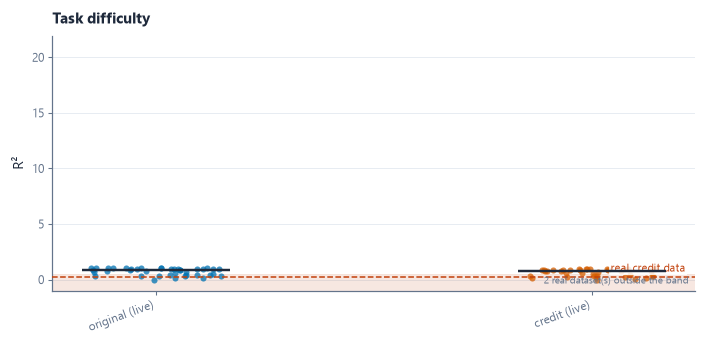

In [9]:
REAL_SCORES = summaries.real_difficulty(TASK, REAL)
print("real-data difficulty:", {k: round(v, 3) for k, v in REAL_SCORES.items()})

FIGS.save(
    e1.plot_difficulty_calibration(loaded, REAL_SCORES, task=TASK),
    "difficulty_calibration",
    caption=(
"Predictability of each synthetic dataset under a small ExtraTrees on a 70/30 split, "
"one point per dataset and one column per prior variant, with the median marked. The "
"shaded band spans the same measurement on the real credit datasets."
    ),
);


## 8. What does the model actually see?

Every figure above is a summary statistic. This is the thing itself: one synthetic table
and one real table, same layout, a few rows each. If they obviously differ, no distance
metric rescues the prior; if they do not, a reader believes the rest more readily.


**How to read it.** Shade is the value's rank within its own column, so compare *texture* — how much variation, how many repeats — not individual cells.

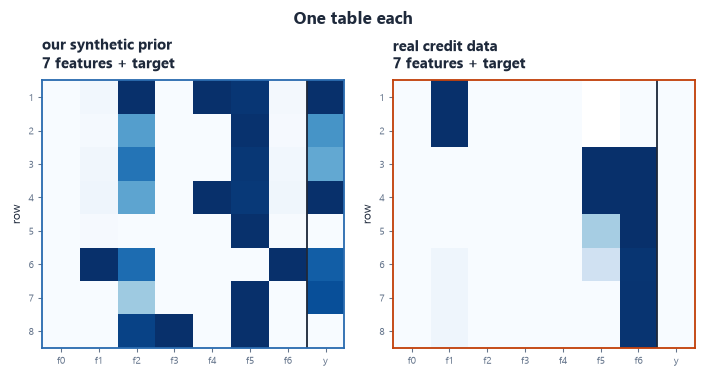

In [10]:
_real_one = next(iter(REAL.values())) if REAL else None
FIGS.save(
    e1.plot_side_by_side_tables(loaded[FOCUS][0], _real_one, task=TASK),
    "side_by_side_tables",
    caption=(
"Eight rows of one synthetic dataset and one real credit dataset, shown as heatmaps "
"with the target as the final column separated by a vertical rule. Each feature is "
"rank-normalised within its own column, so shade encodes relative value rather than "
"units."
    ),
);


## 9. Feature dependence structure

O'Prior's central measurement: the eigenvalue spectrum of the feature correlation
matrix. Two priors whose spectra coincide teach a similar dependence structure however
different their targets look — so this is the check that our changes are not *only*
about the target.


**How to read it.** Two priors whose curves coincide teach a similar feature-dependence structure, however different their targets look.

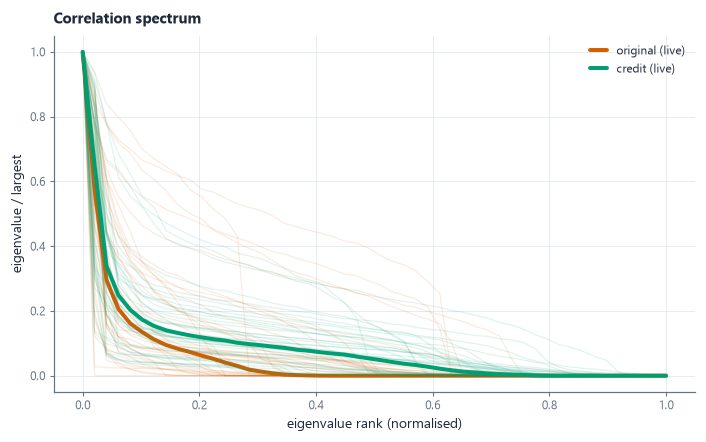

In [11]:
FIGS.save(
    pp.plot_spectrum_by_variant(loaded),
    "spectrum_by_variant",
    caption=(
"Eigenvalue spectra of the feature correlation matrix for up to 40 synthetic datasets "
"per prior variant, normalised by the largest eigenvalue and plotted against "
"normalised eigenvalue rank. Faint lines are individual datasets; bold lines are the "
"per-variant median."
    ),
);


## 10. Shape sanity check

Rows and features per synthetic dataset, against the real datasets. Cheap, and it
catches a misconfigured prior immediately.


**How to read it.** These should MATCH across priors. A difference here is a confound, not a finding.

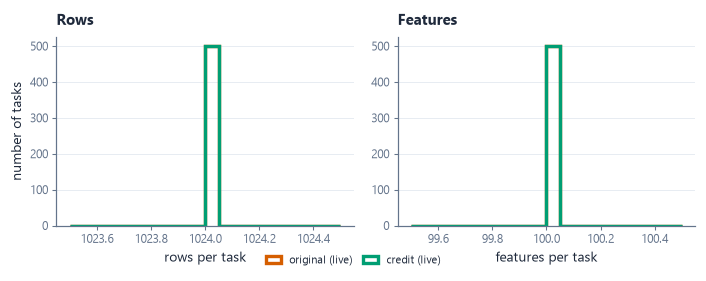

In [12]:
FIGS.save(
    pp.plot_shapes_by_variant(loaded),
    "shapes_by_variant",
    caption=(
"Left: distribution of rows per synthetic dataset. Right: distribution of features "
"per synthetic dataset. One step histogram per prior variant, 20 bins."
    ),
);


## 11. Adjusted prior — boundary-atom intensity

In [ ]:
FIGS.save(
    mechanism_plots.intensity_atoms(CONFIG, n=50),
    'adj_intensity_atoms',
    caption=(
        "Histogram of the pooled LGD target over ~50 synthetic tasks from each prior: the original TabICL prior (grey) and our prior at mild (light blue) and aggressive (dark blue) boundary intensity. Spikes at 0 and 1 are the boundary atoms; the panel subtitle gives the mean total boundary mass."
    ),
);

## 12. Adjusted prior — distribution shift (context vs query)

In [ ]:
FIGS.save(
    mechanism_plots.shift_kinds(CONFIG, n=40),
    'adj_shift_kinds',
    caption=(
        "LGD target in the context rows (grey) versus the query rows (orange), one panel per distribution-shift kind, ~40 tasks each with that shift forced on. Cohort and prior-probability shifts move the target; covariate shift moves the shown feature instead, leaving the target relationship intact."
    ),
);

## 13. Adjusted prior — informative missingness (MNAR)

In [ ]:
FIGS.save(
    mechanism_plots.informative_missingness(TASK),
    'adj_informative_missingness',
    caption=(
        "Missing rate as a function of the LGD outcome for a controlled dataset, under missing-completely-at-random (grey, coupling 0) and target-coupled missingness (blue, coupling 2). Under coupling the rate rises with the outcome; under MCAR it is flat."
    ),
);

## 14. Adjusted prior — predictability filter

In [ ]:
FIGS.save(
    mechanism_plots.filter_modes(CONFIG, n=60),
    'adj_filter_modes',
    caption=(
        "Distribution of ExtraTrees pseudo-R^2 over ~60 generated LGD tasks. The shaded band is what filter mode 'banded' keeps; 'off' keeps all, 'tabicl' keeps the predictable tail."
    ),
);

---

## Summary

Everything above, as text. This is what `output/All_Results.md` collects.


In [13]:
print(summaries.prior_summary(loaded, TASK, source=SOURCE, reference=REFERENCE))
print()
print(summaries.realism_summary(loaded, REAL, TASK))
print()
print(FIGS.summary())



PRIOR SUMMARY — LGD
data source      : live  ('pool' = the files training reads; 'live' = generated on the fly now)
variants compared: original (live), credit (live)
datasets sampled : original (live)=500, credit (live)=500

--- PER VARIANT --------------------------------------------------------------

original (live):
  shape          rows 1024 to 1024 (median 1024) | features 100 to 100 (median 100)
  in [0,1]       0.6% of datasets
  boundary mass  0.2% to 100.0% (median 1.0%)
    at its own min       mean 6.2%  (NOT 0)
    at its own max       mean 4.4%  (NOT 1)
    target is not on [0,1], so these are scale-free ties at the extremes,
      largely the +-4 SD outlier clamp — not recovery or loss.
  any atoms      49.8% of datasets

credit (live):
  shape          rows 1024 to 1024 (median 1024) | features 100 to 100 (median 100)
  in [0,1]       100.0% of datasets
  boundary mass  6.9% to 58.7% (median 32.1%)
    at 0 (full recovery) mean 16.5%
    at 1 (total loss)    mean 15.2%